# BBC training with GRID pretrained encoder

Transfer learning: загружаем веса из GRID checkpoint (val_acc=0.59)
и дообучаем на BBC merged dataset.

**Что переносится:**
- CNN (stem + mbconv_blocks) — выучил извлечение признаков губ
- Transformer encoder (2 слоя) — выучил временные зависимости
- Decoder transformer layer — частично перенесётся

**Что инициализируется заново (vocab отличается, 55 vs 1200):**
- Embedding [1200, 48]
- fc_out [48, 1200]

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pickle
import numpy as np
import copy
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
from tokenizers import Tokenizer

from model_mbconv import LipReadingTransformerMBConv

## Гиперпараметры и конфигурация

In [2]:
# %pip install --upgrade tokenizers

from model_mbconv import load_config

# ── Пути и сплиты ──
DATA_PATH         = "D:/Datasets/Dataset_720_reprocess"
MODEL_CONFIG_PATH = "configs/model_config_mbconv_micro_merged.json"
TOKENIZER_PATH    = "configs/tokenizer_lipreading_1500.json"

TRAIN_CLIPS = [f"pt{i}" for i in range(1, 17)]   # pt1 – pt16 (16 клипов)
VAL_CLIPS   = [f"pt{i}" for i in range(17, 19)]   # pt17 – pt18
TEST_CLIPS  = [f"pt{i}" for i in range(19, 21)]   # pt19 – pt20

# ── Загрузка конфига модели ──
MODEL_CONFIG = load_config(MODEL_CONFIG_PATH)
MODEL_CONFIG["vocab_size"] = 1500   # override: новый токенизатор на 1500 токенов

VOCAB_SIZE = MODEL_CONFIG["vocab_size"]
MAX_FRAMES = MODEL_CONFIG["max_frames"]
MAX_TOKENS = MODEL_CONFIG["max_tokens"]

# ── Скользящее окно ──
FRAME_STRIDE      = 10
TOKEN_CONTENT_LEN = MAX_TOKENS - 1
TOKEN_STRIDE      = 3

# ── Специальные токены из BPE-токенизатора ──
bpe_tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
PAD_TOKEN_ID  = bpe_tokenizer.token_to_id("<|pad|>")
BOS_TOKEN_ID  = bpe_tokenizer.token_to_id("<|bos|>")
EOS_TOKEN_ID  = bpe_tokenizer.token_to_id("<|eos|>")

# ── Обучение ──
BATCH_SIZE    = 12
NUM_EPOCHS    = 400
WARMUP_EPOCHS = 5
LEARNING_RATE = 5e-4
WEIGHT_DECAY  = 1e-3
PATIENCE      = 100

# ── Заморозка визуального CNN энкодера ──
FREEZE_CNN        = False
FREEZE_MIN_EPOCH  = 20
FREEZE_GRACE      = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Dataset: {DATA_PATH}")
print(f"Tokenizer: {TOKENIZER_PATH}")
print(f"Config: d_model={MODEL_CONFIG['d_model']}, nhead={MODEL_CONFIG['nhead']}, "
      f"num_layers={MODEL_CONFIG['num_layers']}, dropout={MODEL_CONFIG['dropout']}")
print(f"vocab_size: {VOCAB_SIZE}")
print(f"Спец-токены: PAD={PAD_TOKEN_ID}, BOS={BOS_TOKEN_ID}, EOS={EOS_TOKEN_ID}")
print(f"Splits: train={len(TRAIN_CLIPS)}, val={len(VAL_CLIPS)}, test={len(TEST_CLIPS)}")
print(f"LR={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}, patience={PATIENCE}")


Device: cuda
Dataset: D:/Datasets/Dataset_720_reprocess
Tokenizer: configs/tokenizer_lipreading_1500.json
Config: d_model=48, nhead=2, num_layers=2, dropout=0.5
vocab_size: 1500
Спец-токены: PAD=0, BOS=1, EOS=2
Splits: train=16, val=2, test=2
LR=0.0005, weight_decay=0.001, patience=100


## Dataset со скользящим окном и аугментацией

In [3]:
class LipReadingDataset(Dataset):
    """
    Загружает .pkl-файлы из указанных клипов.
    Если кадров > MAX_FRAMES, нарезает скользящим окном:
        кадры:  окно 40, сдвиг 10
        токены: окно 11, сдвиг 3

    augment=True включает случайные искажения кадров (только для train):
        - яркость ×[0.7, 1.3]
        - контраст (сдвиг вокруг 0.5) ×[0.8, 1.2]
        - гауссов шум σ=0.02
    Горизонтальный флип НЕ применяется: губы асимметричны при чтении.
    """

    def __init__(self, data_path, clip_names,
                 max_frames=MAX_FRAMES, frame_stride=FRAME_STRIDE,
                 max_tokens=MAX_TOKENS, token_stride=TOKEN_STRIDE,
                 augment=False):
        self.max_frames = max_frames
        self.max_tokens = max_tokens
        self.token_content_len = max_tokens - 1
        self.augment = augment

        data_path = Path(data_path)
        self.samples = []  # (pkl_path, frame_start, token_start, actual_frames)

        for clip_name in sorted(clip_names):
            clip_dir = data_path / clip_name
            if not clip_dir.exists():
                print(f"[!] Папка {clip_dir} не найдена, пропуск")
                continue

            pkl_files = sorted(
                clip_dir.glob("*.pkl"),
                key=lambda f: int(f.stem.split("_")[-1])
            )

            for pkl_file in pkl_files:
                with open(pkl_file, "rb") as f:
                    data = pickle.load(f)

                num_frames = data["num_frames"]
                num_tokens = len(data["input_ids"])

                if num_frames <= max_frames:
                    self.samples.append((str(pkl_file), 0, 0, num_frames))
                else:
                    f_start, t_start = 0, 0
                    while f_start + max_frames <= num_frames:
                        t_end = min(t_start + self.token_content_len, num_tokens)
                        if t_end > t_start:
                            self.samples.append((str(pkl_file), f_start, t_start, max_frames))
                        f_start += frame_stride
                        t_start += token_stride

        aug_str = "+ augment" if augment else ""
        print(f"Загружено {len(self.samples)} сэмплов из {len(clip_names)} клипов {aug_str}")

    def _augment_frames(self, chunk):
        """chunk: float32 (T, C, H, W) в [0, 1]"""
        # Случайная яркость
        if np.random.rand() > 0.5:
            factor = np.float32(np.random.uniform(0.7, 1.3))
            chunk = np.clip(chunk * factor, 0.0, 1.0)

        # Случайный контраст (масштаб вокруг 0.5)
        if np.random.rand() > 0.5:
            factor = np.float32(np.random.uniform(0.8, 1.2))
            chunk = np.clip((chunk - 0.5) * factor + 0.5, 0.0, 1.0)

        # Гауссов шум
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.02, chunk.shape).astype(np.float32)
            chunk = np.clip(chunk + noise, 0.0, 1.0)

        return chunk

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pkl_path, f_start, t_start, actual_frames = self.samples[idx]

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)

        frames = data["frames"]
        ids    = data["input_ids"]

        # ── Кадры ──
        chunk = frames[f_start : f_start + self.max_frames]
        chunk = np.stack(chunk)                                       # (T, H, W, C)
        chunk = np.transpose(chunk, (0, 3, 1, 2)).astype(np.float32) / 255.0  # (T, C, H, W)

        n_real_frames = chunk.shape[0]
        if n_real_frames < self.max_frames:
            pad = np.zeros(
                (self.max_frames - n_real_frames, *chunk.shape[1:]),
                dtype=np.float32,
            )
            chunk = np.concatenate([chunk, pad], axis=0)

        if self.augment:
            chunk = self._augment_frames(chunk)

        src_padding_mask = [False] * n_real_frames + [True] * (self.max_frames - n_real_frames)

        # ── Токены ──
        content = ids[t_start : t_start + self.token_content_len]

        decoder_input = [BOS_TOKEN_ID] + content
        target        = content + [EOS_TOKEN_ID]

        dec_len = len(decoder_input)
        decoder_input += [PAD_TOKEN_ID] * (self.max_tokens - dec_len)
        target        += [PAD_TOKEN_ID] * (self.max_tokens - len(target))

        tgt_padding_mask = [False] * dec_len + [True] * (self.max_tokens - dec_len)

        return {
            "frames":           torch.tensor(chunk, dtype=torch.float32),
            "src_padding_mask": torch.tensor(src_padding_mask, dtype=torch.bool),
            "decoder_input":    torch.tensor(decoder_input, dtype=torch.long),
            "target":           torch.tensor(target, dtype=torch.long),
            "tgt_padding_mask": torch.tensor(tgt_padding_mask, dtype=torch.bool),
        }

## Создание датасетов и загрузчиков

In [4]:
# augment=True только для train — val и test всегда без искажений
train_dataset = LipReadingDataset(DATA_PATH, TRAIN_CLIPS, augment=True)
val_dataset   = LipReadingDataset(DATA_PATH, VAL_CLIPS,   augment=False)
test_dataset  = LipReadingDataset(DATA_PATH, TEST_CLIPS,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

batch = next(iter(train_loader))
print("frames:          ", batch["frames"].shape)
print("src_padding_mask:", batch["src_padding_mask"].shape)
print("decoder_input:   ", batch["decoder_input"].shape)
print("target:          ", batch["target"].shape)
print("tgt_padding_mask:", batch["tgt_padding_mask"].shape)

Загружено 2189 сэмплов из 16 клипов + augment
Загружено 149 сэмплов из 2 клипов 
Загружено 124 сэмплов из 2 клипов 
frames:           torch.Size([12, 40, 3, 64, 96])
src_padding_mask: torch.Size([12, 40])
decoder_input:    torch.Size([12, 12])
target:           torch.Size([12, 12])
tgt_padding_mask: torch.Size([12, 12])


## Взвешенный loss: подсчёт частот токенов

In [5]:
# Считаем частоты токенов по train-набору.
# Цель: модель не должна схлопываться в предсказание самого частого токена.
# Веса = обратная частота, нормированная на число уникальных токенов.

token_counts = Counter()
seen_files = set()
for pkl_path, _, _, _ in train_dataset.samples:
    if pkl_path in seen_files:
        continue
    seen_files.add(pkl_path)
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    token_counts.update(data["input_ids"])

total = sum(token_counts.values())
token_weights = torch.ones(VOCAB_SIZE, dtype=torch.float32)
for token_id, cnt in token_counts.items():
    if token_id < VOCAB_SIZE:
        token_weights[token_id] = total / (len(token_counts) * cnt)
token_weights = token_weights.clamp(max=10.0)

# ── Исправление весов спец-токенов ──
# EOS не входит в input_ids → получал дефолтный вес 1.0, что в ~45× больше
# среднего веса обычных токенов. Это провоцирует модель всегда предсказывать EOS.
avg_weight = token_weights[token_weights < 10.0].mean().item()
token_weights[EOS_TOKEN_ID] = avg_weight   # EOS — не «бесценный»
token_weights[BOS_TOKEN_ID] = 0.0          # BOS никогда не является таргетом
token_weights[PAD_TOKEN_ID] = 0.0          # PAD исключён через ignore_index

print(f"Уникальных токенов в train: {len(token_counts)}")
print(f"Средний вес обычного токена: {avg_weight:.4f}")
print(f"Топ-5 частых:  {token_counts.most_common(5)}")
print(f"Топ-5 редких:  {token_counts.most_common()[:-6:-1]}")
dot_id = bpe_tokenizer.token_to_id(".")
if dot_id is not None:
    print(f"Вес токена '.': {token_weights[dot_id]:.4f}")
print(f"Вес EOS:   {token_weights[EOS_TOKEN_ID]:.4f}")
print(f"Диапазон весов: [{token_weights[token_weights > 0].min():.3f}, {token_weights.max():.3f}]")

Уникальных токенов в train: 1316
Средний вес обычного токена: 2.4800
Топ-5 частых:  [(45, 351), (51, 210), (14, 205), (54, 192), (61, 142)]
Топ-5 редких:  [(901, 1), (782, 1), (794, 1), (1108, 1), (1291, 1)]
Вес EOS:   2.4800
Диапазон весов: [0.019, 6.732]


## Модель, оптимизатор, функция потерь

In [6]:
model = LipReadingTransformerMBConv(MODEL_CONFIG).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(optimizer, start_factor=0.05, total_iters=WARMUP_EPOCHS)
main_scheduler   = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - WARMUP_EPOCHS)//2, eta_min=1e-6)
scheduler        = SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler],
                                milestones=[WARMUP_EPOCHS])

# Взвешенный loss БЕЗ label_smoothing.
# label_smoothing конфликтует с весами: оба механизма правят целевое распределение
# в разных направлениях → нестабильный градиентный сигнал.
criterion = nn.CrossEntropyLoss(
    weight=token_weights.to(DEVICE),
    ignore_index=PAD_TOKEN_ID,
    label_smoothing=0.0,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметры: {total_params:,} всего, {trainable_params:,} обучаемых")

Параметры: 239,494 всего, 239,494 обучаемых


### Загрузка GRID-предобученных весов

Загружаем из `../grid_experiment/best_model_grid.pt` все совместимые веса.
Embedding и fc_out (зависят от vocab_size) останутся random init.

In [7]:
GRID_CHECKPOINT = '../grid_experiment/best_model_grid.pt'

grid_state = torch.load(GRID_CHECKPOINT, map_location=DEVICE)
model_state = model.state_dict()

# Фильтруем веса: совместимые формы только
compatible = {}
incompatible = []
for k, v in grid_state.items():
    if k in model_state and model_state[k].shape == v.shape:
        compatible[k] = v
    else:
        incompatible.append((k, v.shape, model_state[k].shape if k in model_state else 'NOT FOUND'))

missing, unexpected = model.load_state_dict(compatible, strict=False)

print(f'Загружено совместимых тензоров: {len(compatible)}')
print(f'Несовместимые (random init): {len(incompatible)}')
for k, src_shape, dst_shape in incompatible[:10]:
    print(f'  {k}: GRID={src_shape}, BBC={dst_shape}')
print()
print(f'Missing keys: {len(missing)}')
for k in missing[:10]:
    print(f'  {k}')
print(f'Unexpected keys: {len(unexpected)}')

total_params = sum(p.numel() for p in model.parameters())
loaded_params = sum(v.numel() for v in compatible.values())
print(f'Перенесено параметров: {loaded_params:,} из {total_params:,} ({100*loaded_params/total_params:.1f}%)')


Загружено совместимых тензоров: 106
Несовместимые (random init): 5
  encoder.pos_encoding.pe: GRID=torch.Size([1, 150, 48]), BBC=torch.Size([1, 128, 48])
  decoder.embedding.weight: GRID=torch.Size([55, 48]), BBC=torch.Size([1500, 48])
  decoder.pos_encoding.pe: GRID=torch.Size([1, 8, 48]), BBC=torch.Size([1, 12, 48])
  decoder.fc_out.weight: GRID=torch.Size([55, 48]), BBC=torch.Size([1500, 48])
  decoder.fc_out.bias: GRID=torch.Size([55]), BBC=torch.Size([1500])

Missing keys: 5
  encoder.pos_encoding.pe
  decoder.embedding.weight
  decoder.pos_encoding.pe
  decoder.fc_out.weight
  decoder.fc_out.bias
Unexpected keys: 0
Перенесено параметров: 95,075 из 239,494 (39.7%)


## Функции обучения и валидации

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device, log_grads=False):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    grad_log = {"enc_cnn": 0.0, "enc_tr": 0.0, "dec": 0.0, "n": 0}

    for batch in loader:
        frames       = batch["frames"].to(device)
        src_pad_mask = batch["src_padding_mask"].to(device)
        dec_input    = batch["decoder_input"].to(device)
        target       = batch["target"].to(device)
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()

        if log_grads:
            def _gnorm(params):
                return sum(p.grad.norm().item()**2 for p in params if p.grad is not None) ** 0.5
            grad_log["enc_cnn"] += _gnorm(list(model.encoder.stem.parameters()) + list(model.encoder.mbconv_blocks.parameters()))
            grad_log["enc_tr"]  += _gnorm(model.encoder.transformer_encoder.parameters())
            grad_log["dec"]     += _gnorm(model.decoder.parameters())
            grad_log["n"]       += 1

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)

        preds = logits.argmax(dim=-1)
        mask  = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0

    if log_grads and grad_log["n"] > 0:
        n = grad_log["n"]
        print(f"  GradNorm | enc_cnn={grad_log['enc_cnn']/n:.4f} "
              f"enc_tr={grad_log['enc_tr']/n:.4f} dec={grad_log['dec']/n:.4f}")

    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for batch in loader:
        frames       = batch["frames"].to(device)
        src_pad_mask = batch["src_padding_mask"].to(device)
        dec_input    = batch["decoder_input"].to(device)
        target       = batch["target"].to(device)
        tgt_pad_mask = batch["tgt_padding_mask"].to(device)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        total_loss += loss.item() * frames.size(0)

        preds = logits.argmax(dim=-1)
        mask  = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, accuracy

## Цикл обучения с early stopping

### Диагностика: overfit на одном батче

Если модель не может выучить один батч за 300 шагов — есть архитектурная
проблема. Ожидаемый результат: `acc → 0.9+`.

In [9]:
# _model_dbg = LipReadingTransformerMBConv(MODEL_CONFIG).to(DEVICE)
# _opt_dbg   = torch.optim.Adam(_model_dbg.parameters(), lr=1e-3)
# _crit_dbg  = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID)

# _b      = next(iter(train_loader))
# _frames = _b["frames"].to(DEVICE)
# _src_m  = _b["src_padding_mask"].to(DEVICE)
# _dec_in = _b["decoder_input"].to(DEVICE)
# _tgt    = _b["target"].to(DEVICE)
# _tgt_m  = _b["tgt_padding_mask"].to(DEVICE)

# print("Overfit-тест (чистый CE loss, lr=1e-3):")
# for step in range(301):
#     _logits = _model_dbg(_frames, _dec_in, tgt_padding_mask=_tgt_m, src_padding_mask=_src_m)
#     _loss   = _crit_dbg(_logits.reshape(-1, VOCAB_SIZE), _tgt.reshape(-1))
#     _opt_dbg.zero_grad()
#     _loss.backward()
#     _opt_dbg.step()
#     if step % 50 == 0:
#         _mask = _tgt != PAD_TOKEN_ID
#         _acc  = (_logits.argmax(-1)[_mask] == _tgt[_mask]).float().mean().item()
#         print(f"  Step {step:3d} | loss={_loss.item():.4f} | acc={_acc:.3f}")

# del _model_dbg, _opt_dbg, _crit_dbg

## Load best model

In [10]:
model.load_state_dict(torch.load("best_model_bpe.pt", map_location=DEVICE))

<All keys matched successfully>

In [11]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc     = 0.0
best_val_epoch   = 0
best_model_state = None
patience_counter = 0
cnn_frozen       = False

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Эпохи"):
    log_grads = (epoch % 5 == 1)
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE,
                                            log_grads=log_grads)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ── Patience и checkpoint по val_acc ──
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_val_epoch   = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, "best_model_bpe.pt")
        patience_counter = 0
        marker = " *  (saved)"
    else:
        patience_counter += 1
        marker = f" (patience {patience_counter}/{PATIENCE})"

    # ── Заморозка CNN encoder после пика ──
    # Считаем стагнацию только от FREEZE_MIN_EPOCH, а не от best_val_epoch.
    # Это гарантирует, что CNN получит шанс на прорыв (обычно эпохи 20-25).
    epochs_without_improvement = epoch - max(best_val_epoch, FREEZE_MIN_EPOCH)
    if (FREEZE_CNN
            and not cnn_frozen
            and epoch >= FREEZE_MIN_EPOCH
            and epochs_without_improvement >= FREEZE_GRACE):
        for p in model.encoder.stem.parameters():
            p.requires_grad = False
        for p in model.encoder.mbconv_blocks.parameters():
            p.requires_grad = False
        cnn_frozen = True
        frozen_params = sum(1 for p in model.parameters() if not p.requires_grad)
        print(f"  >>> CNN encoder FROZEN на эпохе {epoch} "
              f"(best_val_acc={best_val_acc:.6f} на эпохе {best_val_epoch}, "
              f"{frozen_params} параметров заморожено)")
        # Пересоздаём optimizer только с обучаемыми параметрами
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=optimizer.param_groups[0]["lr"],
            weight_decay=WEIGHT_DECAY,
        )

    lr = optimizer.param_groups[0]["lr"]
    frozen_tag = " [CNN frozen]" if cnn_frozen else ""
    print(
        f"Epoch {epoch:3d} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.6f} | "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.6f} | "
        f"lr={lr:.2e}{marker}{frozen_tag}"
    )

    if patience_counter >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}")
        break

print(f"Обучение завершено. best val_acc={best_val_acc:.6f} (эпоха {best_val_epoch})")

Эпохи:   0%|          | 0/400 [00:00<?, ?it/s]

c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


  GradNorm | enc_cnn=1.4806 enc_tr=0.6705 dec=2.7788


c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ..\aten\src\ATen\native\transformers\attention.cpp:152.)
  return torch._native_multi_head_attention(


Epoch   1 | train_loss=4.7360  train_acc=0.122794 | val_loss=6.4151  val_acc=0.132184 | lr=1.20e-04 *  (saved)
Epoch   2 | train_loss=4.7449  train_acc=0.121486 | val_loss=6.4177  val_acc=0.128900 | lr=2.15e-04 (patience 1/100)
Epoch   3 | train_loss=4.7212  train_acc=0.121214 | val_loss=6.4386  val_acc=0.131363 | lr=3.10e-04 (patience 2/100)
Epoch   4 | train_loss=4.6995  train_acc=0.123121 | val_loss=6.4827  val_acc=0.122332 | lr=4.05e-04 (patience 3/100)


c:\Users\Maksim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch   5 | train_loss=4.6552  train_acc=0.123012 | val_loss=6.4611  val_acc=0.123974 | lr=5.00e-04 (patience 4/100)
  GradNorm | enc_cnn=1.3225 enc_tr=0.6694 dec=2.9983
Epoch   6 | train_loss=4.5742  train_acc=0.124047 | val_loss=6.5330  val_acc=0.119869 | lr=5.00e-04 (patience 5/100)
Epoch   7 | train_loss=4.5026  train_acc=0.125735 | val_loss=6.6021  val_acc=0.113300 | lr=5.00e-04 (patience 6/100)
Epoch   8 | train_loss=4.3999  train_acc=0.127043 | val_loss=6.6312  val_acc=0.114943 | lr=5.00e-04 (patience 7/100)
Epoch   9 | train_loss=4.3388  train_acc=0.127969 | val_loss=6.6902  val_acc=0.113300 | lr=4.99e-04 (patience 8/100)
Epoch  10 | train_loss=4.2568  train_acc=0.131347 | val_loss=6.7285  val_acc=0.110016 | lr=4.99e-04 (patience 9/100)
  GradNorm | enc_cnn=1.2221 enc_tr=0.6279 dec=3.0589
Epoch  11 | train_loss=4.1716  train_acc=0.133144 | val_loss=6.8159  val_acc=0.096059 | lr=4.99e-04 (patience 10/100)
Epoch  12 | train_loss=4.1065  train_acc=0.134997 | val_loss=6.8894  val_a

## Графики обучения

График сохранён: training_plots\bpe_D48_L2_H2_drop0.5_lr0.0005_20260430_212537.png


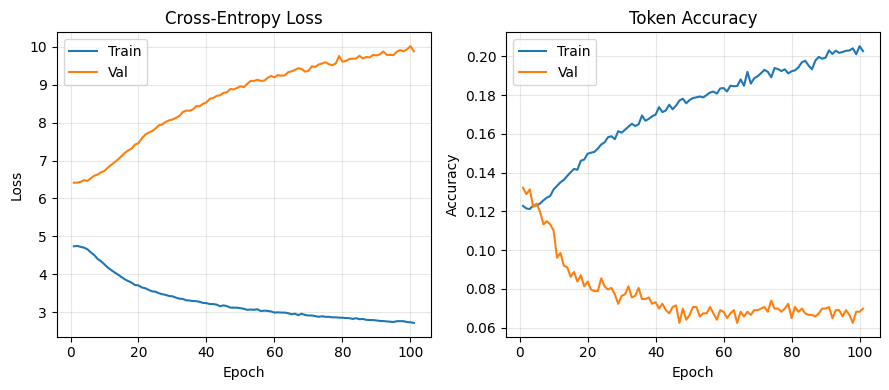

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Token Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Уникальное имя: параметры модели + временная метка
PLOTS_DIR = Path("training_plots")
PLOTS_DIR.mkdir(exist_ok=True)
_ts    = datetime.now().strftime("%Y%m%d_%H%M%S")
_fname = (
    f"bpe"
    f"_D{MODEL_CONFIG['d_model']}"
    f"_L{MODEL_CONFIG['num_layers']}"
    f"_H{MODEL_CONFIG['nhead']}"
    f"_drop{MODEL_CONFIG['dropout']}"
    f"_lr{LEARNING_RATE}"
    f"_{_ts}.png"
)
plt.savefig(PLOTS_DIR / _fname, dpi=150)
print(f"График сохранён: {PLOTS_DIR / _fname}")
plt.show()

## Оценка на тестовом наборе

## Resume: продолжить обучение с лучшей модели

Загружаем лучшую модель (по val_acc) и продолжаем обучение.

**Почему без warmup:**
- Warmup нужен только для случайных весов (стабилизация градиентов)
- Загруженная модель уже в рабочей области — стартуем сразу с рабочего LR

**Почему свежий optimizer:**
- Optimizer хранит momentum/velocity (Adam state) от предыдущего прогона
- Если предыдущий прогон закончился переобучением, этот импульс вреден
- Чистый optimizer начинает накапливать статистику заново

In [13]:
# ── Параметры resume ──
RESUME_LR       = 5e-4    # ниже пикового, модель уже обучена
RESUME_WD       = 1e-3    # тот же weight_decay что в основном прогоне
RESUME_CLIP     = 1.0
RESUME_EPOCHS   = 200
RESUME_PATIENCE = 50      # patience по val_acc

# Загружаем лучшую модель (по val_acc)
model.load_state_dict(torch.load("best_model_bpe.pt", map_location=DEVICE))
print(f"Загружена лучшая модель из best_model_bpe.pt")

# Свежий optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=RESUME_LR, weight_decay=RESUME_WD)
scheduler = CosineAnnealingLR(optimizer, T_max=RESUME_EPOCHS // 2, eta_min=1e-6)

print(f"Resume: LR={RESUME_LR}, weight_decay={RESUME_WD}, grad_clip={RESUME_CLIP}")

# ── Цикл дообучения (patience по val_acc) ──
history_r = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_r     = 0.0
best_model_state_r = None
patience_counter_r = 0

for epoch in tqdm(range(1, RESUME_EPOCHS + 1), desc="Resume"):
    log_grads = (epoch % 10 == 1)

    model.train()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    grad_log = {"enc_cnn": 0.0, "enc_tr": 0.0, "dec": 0.0, "n": 0}

    for batch in train_loader:
        frames       = batch["frames"].to(DEVICE)
        src_pad_mask = batch["src_padding_mask"].to(DEVICE)
        dec_input    = batch["decoder_input"].to(DEVICE)
        target       = batch["target"].to(DEVICE)
        tgt_pad_mask = batch["tgt_padding_mask"].to(DEVICE)

        logits = model(frames, dec_input,
                       tgt_padding_mask=tgt_pad_mask,
                       src_padding_mask=src_pad_mask)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()

        if log_grads:
            def _gnorm(params):
                return sum(p.grad.norm().item()**2 for p in params if p.grad is not None) ** 0.5
            grad_log["enc_cnn"] += _gnorm(list(model.encoder.stem.parameters()) + list(model.encoder.mbconv_blocks.parameters()))
            grad_log["enc_tr"]  += _gnorm(model.encoder.transformer_encoder.parameters())
            grad_log["dec"]     += _gnorm(model.decoder.parameters())
            grad_log["n"]       += 1

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=RESUME_CLIP)
        optimizer.step()

        total_loss += loss.item() * frames.size(0)
        preds = logits.argmax(dim=-1)
        mask  = target != PAD_TOKEN_ID
        total_correct += (preds[mask] == target[mask]).sum().item()
        total_tokens  += mask.sum().item()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc  = total_correct / total_tokens if total_tokens > 0 else 0.0

    if log_grads and grad_log["n"] > 0:
        n = grad_log["n"]
        print(f"  GradNorm | enc_cnn={grad_log['enc_cnn']/n:.4f} "
              f"enc_tr={grad_log['enc_tr']/n:.4f} dec={grad_log['dec']/n:.4f}")

    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history_r["train_loss"].append(train_loss)
    history_r["val_loss"].append(val_loss)
    history_r["train_acc"].append(train_acc)
    history_r["val_acc"].append(val_acc)

    if val_acc > best_val_acc_r:
        best_val_acc_r     = val_acc
        best_model_state_r = copy.deepcopy(model.state_dict())
        # Сохраняем СРАЗУ
        torch.save(best_model_state_r, "best_model_bpe_resume.pt")
        patience_counter_r = 0
        marker = " *  (saved)"
    else:
        patience_counter_r += 1
        marker = f" (patience {patience_counter_r}/{RESUME_PATIENCE})"

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"R-Epoch {epoch:3d} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.6f} | "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.6f} | "
        f"lr={lr:.2e}{marker}"
    )

    if patience_counter_r >= RESUME_PATIENCE:
        print(f"\nEarly stopping на R-Epoch {epoch}")
        break

print(f"\nResume завершён. best val_acc={best_val_acc_r:.6f}")

Загружена лучшая модель из best_model_bpe.pt
Resume: LR=0.0005, weight_decay=0.001, grad_clip=1.0


Resume:   0%|          | 0/200 [00:00<?, ?it/s]

  GradNorm | enc_cnn=1.5070 enc_tr=0.7092 dec=2.8786
R-Epoch   1 | train_loss=4.8838  train_acc=0.121541 | val_loss=6.4469  val_acc=0.127258 | lr=5.00e-04 *  (saved)
R-Epoch   2 | train_loss=4.7469  train_acc=0.123175 | val_loss=6.4519  val_acc=0.128079 | lr=5.00e-04 *  (saved)
R-Epoch   3 | train_loss=4.6656  train_acc=0.123175 | val_loss=6.4662  val_acc=0.123974 | lr=4.99e-04 (patience 1/50)
R-Epoch   4 | train_loss=4.5795  train_acc=0.126226 | val_loss=6.5066  val_acc=0.114122 | lr=4.98e-04 (patience 2/50)
R-Epoch   5 | train_loss=4.4811  train_acc=0.126389 | val_loss=6.5978  val_acc=0.109195 | lr=4.97e-04 (patience 3/50)
R-Epoch   6 | train_loss=4.3886  train_acc=0.129222 | val_loss=6.6052  val_acc=0.108374 | lr=4.96e-04 (patience 4/50)
R-Epoch   7 | train_loss=4.2996  train_acc=0.128950 | val_loss=6.6405  val_acc=0.106732 | lr=4.94e-04 (patience 5/50)
R-Epoch   8 | train_loss=4.2268  train_acc=0.131619 | val_loss=6.7010  val_acc=0.106732 | lr=4.92e-04 (patience 6/50)
R-Epoch   9 |

In [16]:
model.load_state_dict(torch.load("best_model_bpe.pt", map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test token accuracy: {test_acc:.3f}")

Test loss: 6.9050
Test token accuracy: 0.097


## Пример инференса (greedy decode)

In [17]:
@torch.no_grad()
def greedy_decode(model, video_frames, max_len=MAX_TOKENS, device=DEVICE):
    """Авторегрессионная генерация токенов по видео."""
    model.eval()
    video = video_frames.unsqueeze(0).to(device)

    memory = model.encoder(video)
    if isinstance(memory, tuple):
        memory = memory[0]

    generated = [BOS_TOKEN_ID]

    for _ in range(max_len - 1):
        tgt = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model.decoder(tgt, memory)
        next_token = logits[0, -1].argmax().item()
        generated.append(next_token)
        if next_token == EOS_TOKEN_ID:
            break

    tokens = [t for t in generated if t not in (BOS_TOKEN_ID, EOS_TOKEN_ID, PAD_TOKEN_ID)]
    return tokens


for i in range(min(5, len(test_dataset))):
    sample    = test_dataset[i]
    pred_ids  = greedy_decode(model, sample["frames"])
    pred_text = bpe_tokenizer.decode(pred_ids)

    gt_ids  = [t for t in sample["target"].tolist()
               if t not in (EOS_TOKEN_ID, PAD_TOKEN_ID)]
    gt_text = bpe_tokenizer.decode(gt_ids)

    print(f"[{i}] Predicted:    {pred_text}")
    print(f"[{i}] Ground truth: {gt_text}")
    print()

[0] Predicted:    continu
[0] Ground truth: thank you welcome to bbc london on this

[1] Predicted:    
[1] Ground truth: first monday of the new year coming up

[2] Predicted:    
[2] Ground truth: also tonight

[3] Predicted:    
[3] Ground truth: some uh help ful inform ation there and of course uh

[4] Predicted:    ox
[4] Ground truth: kate our weather pres ent er will be here later with

